In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_excel('data/data_ford_price.xlsx')
data.head()

,price,year,condition,cylinders,odometer,title_status,transmission,drive,size,lat,long,weather
0,43900,2016,4,6,43500,clean,automatic,4wd,full-size,36.471500,-82.483400,59.0
1,15490,2009,2,8,98131,clean,automatic,4wd,full-size,40.468826,-74.281734,52.0
2,2495,2002,2,8,201803,clean,automatic,4wd,full-size,42.477134,-82.949564,45.0
3,1300,2000,1,8,170305,rebuilt,automatic,4wd,full-size,40.764373,-82.349503,49.0
4,13865,2010,3,8,166062,clean,automatic,4wd,NaN,49.210949,-123.114720,NaN


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7017 entries, 0 to 7016
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         7017 non-null   int64  
 1   year          7017 non-null   int64  
 2   condition     7017 non-null   int64  
 3   cylinders     7017 non-null   int64  
 4   odometer      7017 non-null   int64  
 5   title_status  7017 non-null   object 
 6   transmission  7017 non-null   object 
 7   drive         6626 non-null   object 
 8   size          5453 non-null   object 
 9   lat           7017 non-null   float64
 10  long          7017 non-null   float64
 11  weather       6837 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 658.0+ KB


In [4]:
data.describe()

,price,year,condition,cylinders,odometer,lat,long,weather
count,7017.000000,7017.000000,7017.000000,7017.000000,7.017000e+03,7017.000000,7017.000000,6837.000000
mean,15121.549523,2007.869745,2.598689,7.374662,1.199787e+05,39.550144,-91.903404,52.142899
std,11765.423119,6.975329,0.703662,0.942928,8.992216e+04,5.745409,14.030710,7.954830
min,1.000000,1957.000000,0.000000,3.000000,0.000000e+00,-2.508807,-151.055832,29.000000
25%,5995.000000,2004.000000,2.000000,6.000000,7.328500e+04,35.661076,-95.937145,45.000000
50%,12750.000000,2010.000000,3.000000,8.000000,1.180000e+05,40.335245,-88.168416,51.000000
75%,21995.000000,2013.000000,3.000000,8.000000,1.578040e+05,43.582100,-82.706300,59.000000
max,299500.000000,2018.000000,5.000000,10.000000,2.490000e+06,77.617682,-5.377999,71.000000


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'condition'}>],
       [<Axes: title={'center': 'cylinders'}>,
        <Axes: title={'center': 'odometer'}>,
        <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'weather'}>, <Axes: >]], dtype=object)

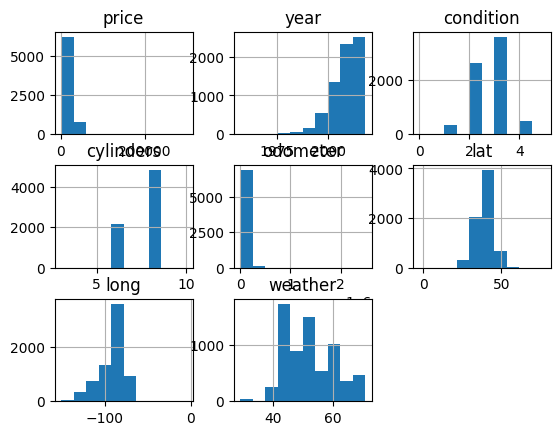

In [5]:
data.hist()

In [6]:
data.value_counts()

price  year  condition  cylinders  odometer  title_status  transmission  drive  size       lat        long        weather
12488  2010  2          8          144570    clean         automatic     4wd    full-size  42.892121  -85.665539  45.0       23
11977  2008  3          8          171488    clean         automatic     4wd    mid-size   44.873130  -87.895680  45.0       21
16995  2002  2          8          65336     clean         automatic     rwd    full-size  33.711509  -78.909582  60.0       20
9550   2006  3          8          168942    clean         automatic     4wd    mid-size   44.873130  -87.895680  45.0       19
23800  2014  3          8          93580     clean         automatic     4wd    full-size  33.066044  -89.593906  61.0       15
                                                                                                                             ..
6999   2004  3          8          122138    clean         automatic     rwd    full-size  27.873066  -82.7867

In [7]:
data.isnull().sum()

price              0
year               0
condition          0
cylinders          0
odometer           0
title_status       0
transmission       0
drive            391
size            1564
lat                0
long               0
weather          180
dtype: int64

In [8]:
y = data['price']
x = data.drop(columns='price')

In [130]:
# lr = linear_model.LinearRegression()
# lr.fit(x, y)

In [9]:
from sklearn.preprocessing  import LabelBinarizer

lb = LabelBinarizer()

education = ['нет', 'начальное', 'среднее', 'BSc', 'MSc', 'начальное', 'PhD']

lb.fit(education)

print('категории:', lb.classes_)

lb.transform(['нет', 'MSc'])

категории: ['BSc' 'MSc' 'PhD' 'начальное' 'нет' 'среднее']


array([[0, 0, 0, 0, 1, 0],
       [0, 1, 0, 0, 0, 0]])

In [10]:
columns_to_change = ['cylinders', 'title_status', 'transmission', 'drive', 'size']

for column in columns_to_change:
 print(f'Число уникальных значений признака {column}: {data[column].nunique()}')

Число уникальных значений признака cylinders: 6
Число уникальных значений признака title_status: 5
Число уникальных значений признака transmission: 3
Число уникальных значений признака drive: 3
Число уникальных значений признака size: 4


Итак, нам подходит однократное кодирование. Применим его к выбранным столбцам. Так как у нас нет отдельной тестовой выборки, то мы используем только один метод — fit_transform(). В качестве аргумента передаём таблицу с выбранными для преобразования признаками.

С помощью метода get_feature_names_out() получим список новых названий колонок:

In [11]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder()

# 'учим' и сразу применяем преобразование к выборке, результат переводим в массив
data_onehot = one_hot_encoder.fit_transform(data[columns_to_change]).toarray()

# запишем полученные названия новых колонок в отдельную переменную
column_names = one_hot_encoder.get_feature_names_out(columns_to_change)
print(column_names)

['cylinders_3' 'cylinders_4' 'cylinders_5' 'cylinders_6' 'cylinders_8'
 'cylinders_10' 'title_status_clean' 'title_status_lien'
 'title_status_missing' 'title_status_rebuilt' 'title_status_salvage'
 'transmission_automatic' 'transmission_manual' 'transmission_other'
 'drive_4wd' 'drive_fwd' 'drive_rwd' 'drive_nan' 'size_compact'
 'size_full-size' 'size_mid-size' 'size_sub-compact' 'size_nan']


Отлично, категориальные признаки закодированы. Теперь нам необходимо соединить преобразованные данные с исходными.

Напомним, что у библиотеки pandas есть дефолтный метод get_dummies() для получения однократного кодирования признаков. Однако OneHotEncoder способен принимать на вход как таблицы, так и numpy-массивы.

In [12]:
df_data_onehot = pd.DataFrame(data_onehot, columns=column_names)
df_data_onehot.head()

,cylinders_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8,cylinders_10,title_status_clean,title_status_lien,title_status_missing,title_status_rebuilt,...,transmission_other,drive_4wd,drive_fwd,drive_rwd,drive_nan,size_compact,size_full-size,size_mid-size,size_sub-compact,size_nan
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [13]:
df_data_onehot.shape

(7017, 23)

In [14]:
data_new = pd.concat([data, df_data_onehot], axis=1)
data_new = data_new.drop(columns=columns_to_change)
data_new.shape

(7017, 30)

Посмотрим, что будет, если просто убрать все строки с пропусками в столбце weather:

In [50]:
data[~data['weather'].isna()]

,year,condition,cylinders,odometer,title_status,transmission,drive,size,lat,long,weather
0,2016,4,6,43500,clean,automatic,4wd,full-size,36.471500,-82.483400,59.0
1,2009,2,8,98131,clean,automatic,4wd,full-size,40.468826,-74.281734,52.0
2,2002,2,8,201803,clean,automatic,4wd,full-size,42.477134,-82.949564,45.0
3,2000,1,8,170305,rebuilt,automatic,4wd,full-size,40.764373,-82.349503,49.0
5,2003,3,8,167662,clean,automatic,4wd,full-size,45.518031,-122.578752,50.0
...,...,...,...,...,...,...,...,...,...,...,...
7010,2017,3,6,22973,clean,automatic,4wd,full-size,34.244046,-77.860915,56.0
7012,2015,3,6,23500,clean,automatic,rwd,full-size,32.680700,-117.169800,59.0
7013,2005,2,8,0,clean,automatic,rwd,full-size,38.213303,-85.785762,50.0
7015,2011,2,8,164000,clean,automatic,4wd,full-size,43.140600,-93.385000,47.0


Символ ~ (тильда) означает, что мы выбираем все строки датасета data, где не выполняется условие data['weather'].isna(), то есть где нет пропусков в столбце 'weather'.

In [16]:
n = data[~data['size'].isna()].shape[0]
print(n)
n_full = data.shape[0]
print(n_full)
print(np.round(n/n_full, 2))

5453
7017
0.78


### РАБОТА С ПРОПУСКАМИ

В качестве регрессора воспользуемся линейной моделью, а качество оценим с помощью коэффициента детерминации. Также нам потребуется разделить модель на обучающую и тестовую выборки.

Удалим данные с пропусками:

In [17]:
x = x.dropna()

Мы удалили некоторые строки из таблицы x. Соответственно, надо сделать то же самое в целевой переменной y.

Выберем все оставшиеся индексы таблицы x с помощью метода index(), а затем используем .iloc[], чтобы получить подгруппу целевых значений, соответствующую полученным индексам.

In [18]:
y = y.iloc[x.index]

In [19]:
x.shape[0] == y.shape[0]

True

Разделим выборку на тренировочную и тестовую в соотношении 80/20:

In [20]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=30)

In [21]:
# Проведём кодирование OneHot-методом категориальных переменных.
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder()

Обучаем энкодер и сразу применяем преобразование к выборке. Результат переводим в массив:

In [22]:
X_train_onehot = one_hot_encoder.fit_transform(X_train[columns_to_change]).toarray()

Затем применяем полученное преобразование к тестовой выборке. Результат переводим в массив:

In [23]:
X_test_onehot = one_hot_encoder.transform(X_test[columns_to_change]).toarray()

Для удобства сохраним полученные названия новых колонок в отдельную переменную:

In [24]:
columns = one_hot_encoder.get_feature_names_out(columns_to_change)
columns[:10]

array(['cylinders_3', 'cylinders_4', 'cylinders_5', 'cylinders_6',
       'cylinders_8', 'cylinders_10', 'title_status_clean',
       'title_status_lien', 'title_status_missing',
       'title_status_rebuilt'], dtype=object)

Теперь у нас есть массив закодированных признаков и наша изначальная таблица. Чтобы соединить эти данные, переведём массив в формат DataFrame.

In [25]:
X_train_onehot_df = pd.DataFrame(X_train_onehot, columns=columns)
X_test_onehot_df = pd.DataFrame(X_test_onehot, columns=columns)

Таблица X_train содержит рандомные индексы, так как мы разделили выборку на train и test. Если просто соединить X_train и X_train_onehot_df, то получится таблица, полная пропусков по причине несовпадения индексов.

Переустановим индексацию в таблицах, применив подряд сразу два метода: reset_index() — для изменения индексов с рандомных на последовательные от 0 до n и drop(['index'], axis = 1) — для удаления образовавшегося столбца 'index'.

In [26]:
X_train = X_train.reset_index().drop(['index'], axis = 1)
X_test = X_test.reset_index().drop(['index'], axis = 1)

y_train = y_train.reset_index().drop(['index'], axis = 1)
y_test = y_test.reset_index().drop(['index'], axis = 1)

Объединяем таблицы и удаляем старые категориальные признаки:

In [27]:
X_train_new = pd.concat([X_train, X_train_onehot_df], axis=1)
X_test_new = pd.concat([X_test, X_test_onehot_df], axis=1)

X_train_new = X_train_new.drop(columns=columns_to_change)
X_test_new = X_test_new.drop(columns=columns_to_change)

Настало время обучить модель. Для этого создаём объект класса LinearRegression.

In [28]:
lr_model = LinearRegression()

Обучаем модель по МНК (метод наименьших квадратов):

In [29]:
lr_model.fit(X_train_new, y_train)

LinearRegression()

Делаем предсказание для тренировочной выборки:

In [30]:
y_train_predict = lr_model.predict(X_train_new)

Делаем предсказание для тестовой выборки:

In [153]:
# y_test_predict = lr_model.predict(X_test_new)
# print("Train R^2: {:.3f}".format(r2_score(y_train, y_train_predict)))
# print("Test R^2: {:.3f}".format(r2_score(y_test, y_test_predict)))

# Train R^2: 0.647
# Test R^2: 0.693

Теперь давайте попробуем заполнить пропуски константными значениями и обучить модель заново. Плюс такого подхода состоит в том, что мы предотвращаем потерю данных, которая происходит при удалении строк или столбцов. Основной минус — в снижении разброса (разнообразия) признаков.

In [154]:
# import numpy as np
#
# X_train['weather'] = X_train['weather'].fillna(np.round(np.mean(X_train['weather']),0))
# X_test['weather'] = X_test['weather'].fillna(np.round(np.mean(X_train['weather']),0))

Для простоты воспользуемся заполнением наиболее частым значением категориальных признаков. Для этого сначала определим их в наших признаках, использовав комбинацию методов value_counts() и head():

In [155]:
# X_train['drive'].value_counts(True).head(1)

# 4wd   0.755447
# Name: drive, dtype: float64

In [156]:
# X_train['size'].value_counts(True).head(1)

# full-size   0.877418
# Name: size, dtype: float64

In [157]:
# X_train['size'] = X_train['size'].fillna('full-size')
# X_train['drive'] = X_train['drive'].fillna('4wd')
#
# X_test['size'] = X_test['size'].fillna('full-size')
# X_test['drive'] = X_test['drive'].fillna('4wd')

После обучения модели получился следующий результат:

In [158]:
# lr_model.fit(X_train_new, y_train)
# y_train_predict_mean_val = lr_model.predict(X_train_new)
#
# y_test_predict_mean_val = lr_model.predict(X_test_new)
# print("Train R^2: {:.3f}".format(r2_score(y_train, y_train_predict_mean_val)))
# print("Test R^2: {:.3f}".format(r2_score(y_test, y_test_predict_mean_val)))

# Train R^2: 0.649
# Test R^2: 0.465

Напомним: модели с коэффициентом детерминации выше 0.8 можно признать достаточно хорошими. Равенство коэффициента детерминации 1 означает, что объясняемая переменная в точности описывается рассматриваемой моделью.

Приведённые методы обработки отсутствующих значений не учитывают корреляционную связь признака, содержащего пропуски, с остальными. Признаки, не имеющие NaN, можно использовать для прогнозирования пропущенных значений. Строится модель регрессии или классификации в зависимости от характера (категорийного или непрерывного) признака, имеющего пропущенное значение.

In [37]:
data = pd.read_excel('data/data_ford_price.xlsx')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7017 entries, 0 to 7016
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         7017 non-null   int64  
 1   year          7017 non-null   int64  
 2   condition     7017 non-null   int64  
 3   cylinders     7017 non-null   int64  
 4   odometer      7017 non-null   int64  
 5   title_status  7017 non-null   object 
 6   transmission  7017 non-null   object 
 7   drive         6626 non-null   object 
 8   size          5453 non-null   object 
 9   lat           7017 non-null   float64
 10  long          7017 non-null   float64
 11  weather       6837 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 658.0+ KB


In [38]:
# Импортируем необходимые модули
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder


# Скопируем данные в отдельную переменную
data = x.copy()

# В качестве тестовой выборки возьмем строки с пропусками в признаке weather
test_data = data[data['weather'].isnull()]
print(test_data.shape)
# И удалим эти строчки из таблицы
data.dropna(inplace=True)

# Определим целевой признак и факторы
y_train = data['weather']
X_train = data.drop(['size','weather','drive'], axis=1)
X_test = test_data.drop(['size','weather','drive'], axis=1)
# print("y_train")
# print(y_train)
# print("X_train")
# print(X_train)
# print("X_test")
# print(X_test)

# Создадим кодировщик
one_hot_encoder = OneHotEncoder()
categorial_cols = ['cylinders', 'title_status', 'transmission']

# Закодируем категориальные признаки (обучаем кодировщик только на тренировочной выборке)
X_train_onehot = one_hot_encoder.fit_transform(X_train[categorial_cols]).toarray()
X_test_onehot = one_hot_encoder.transform(X_test[categorial_cols]).toarray()

# Результаты преобразуем обратно в DataFrame для удобства
columns = one_hot_encoder.get_feature_names_out(categorial_cols)
X_train_onehot_df = pd.DataFrame(X_train_onehot, columns=columns)
X_test_onehot_df = pd.DataFrame(X_test_onehot, columns=columns)

# Сбросим индексы таблиц
X_train = X_train.reset_index().drop(['index'], axis = 1)
X_test = X_test.reset_index().drop(['index'], axis = 1)
y_train = y_train.reset_index().drop(['index'], axis = 1)

# Добавим результаты кодирования к исходным таблицам
X_train_new = pd.concat([X_train, X_train_onehot_df], axis=1)
X_test_new = pd.concat([X_test, X_test_onehot_df], axis=1)

# Удалим столбцы, которые уже были закодированы
X_train_new = X_train_new.drop(columns=categorial_cols)
X_test_new = X_test_new.drop(columns=categorial_cols)

# Создадим модель линейной регрессии и обучим ее на задачу предсказания пропусков
model = LinearRegression()
model.fit(X_train_new, y_train)

# Сделаем предсказание целевой переменной (пропущенных значений в признаке weather)
y_pred = model.predict(X_test_new)

(0, 11)


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

### РАБОТА С ВЫБРОСАМИ

#### Первый алгоритм, который мы применим, — Isolation Forest, или iForest. Это алгоритм обнаружения аномалий на основе дерева.

In [59]:
df_out = pd.read_excel('data/data_ford_price.xlsx')

In [60]:
df_out = df_out[['price', 'year', 'cylinders', 'odometer' ,'lat', 'long', 'weather']]
df_out.dropna(inplace=True)

y = df_out['price']
x = df_out.drop(columns='price')
x.head()

,year,cylinders,odometer,lat,long,weather
0,2016,6,43500,36.471500,-82.483400,59.0
1,2009,8,98131,40.468826,-74.281734,52.0
2,2002,8,201803,42.477134,-82.949564,45.0
3,2000,8,170305,40.764373,-82.349503,49.0
5,2003,8,167662,45.518031,-122.578752,50.0


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=40)

model = LinearRegression()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)

mae = mean_absolute_error(y_test, y_predict)
print('MAE: %.3f' % mae)

MAE: 4682.957


In [62]:
from  sklearn.ensemble import IsolationForest

# ищем выбросы в обучающей выборке
iso = IsolationForest(contamination=0.1)
y_predict = iso.fit_predict(X_train)

# выберем все строки, которые не являются выбросами
mask = y_predict != -1
X_train, y_train = X_train[mask], y_train[mask]
print(X_train.shape, y_train.shape)

model = LinearRegression()
model.fit(X_train, y_train)

y_predict = model.predict(X_test)
mae = mean_absolute_error(y_test, y_predict)
print('MAE: %.3f' % mae)

(4306, 6) (4306,)
MAE: 4441.283


#### Следующий метод — Local Outlier Factor, или LOF. Это метод, который пытается использовать идею ближайших соседей для обнаружения выбросов.

In [63]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor()
y_predicted = lof.fit_predict(X_train)

mask = y_predicted != -1
X_train, y_train = X_train[mask], y_train[mask]

print(X_train.shape, y_train.shape)

model = LinearRegression()
model.fit(X_train, y_train)

y_predicted = model.predict(X_test)
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

(3967, 6) (3967,)
MAE: 4442.900


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
